# LightGBM 이커머스 이탈 예측 모델링

- Baseline부터 최종 모델 확정까지 전체 과정
- `data/preprocessed/`의 전처리된 데이터를 사용하며, **test 데이터는 맨 마지막
최종 평가 전까지 이 노트북에서 전혀 사용하지 않음.**

**평가 기준(팀 합의)**: Recall 우선 (이탈 고객을 놓치지 않는 것이 중요), Precision·AUC 함께 기록.
단, 탐색 단계(Optuna)의 최적화 목표는 AUC를 사용 — Recall만 직접 최적화하면 "전부 이탈로
예측"하는 식의 퇴화해 버릴 수 있어(Recall=1이지만 무의미), threshold에 안정적인 AUC로 좋은 모델을
찾고, 최종 후보 비교/보고는 Recall 중심으로 함.

## 0. 데이터 로드

In [75]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 노트북 실행 위치에 관계없이 프로젝트 루트의 data 폴더를 찾음
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "preprocessed").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_val   = pd.read_csv(DATA_DIR / "X_val.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
y_val   = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1단계: Baseline 모델
하이퍼파라미터 튜닝 없이 LightGBM 기본값 그대로 학습해 기준 성능잡기

In [76]:
baseline_model = LGBMClassifier(random_state=42, verbose=-1)
baseline_model.fit(X_train, y_train)

def evaluate(model, X, y, dataset_name):
    """recall을 맨 앞에 두어 팀 평가 기준(Recall 우선)에 맞춤"""
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "dataset": dataset_name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
        "accuracy": accuracy_score(y, pred),
        "f1": f1_score(y, pred),
    }

baseline_results = pd.DataFrame([
    evaluate(baseline_model, X_train, y_train, "train"),
    evaluate(baseline_model, X_val, y_val, "val"),
])
print(baseline_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.934  0.656
precision  0.914  0.656
auc        0.980  0.741
accuracy   0.924  0.660
f1         0.923  0.656


### 해석
- train recall 0.934 vs val recall 0.656, train AUC 0.980 vs val AUC 0.741 → 여전히 뚜렷한 과적합
- val recall 0.656은 이탈 고객 3명 중 1명 이상을 놓치는 수준 → 다음 단계에서 과적합을 줄이며
  recall도 같이 개선을 노려봄

## 2단계: 정규화 + Early Stopping
트리 복잡도를 제한하고 규제항을 추가해 과적합을 완화합니다.

In [77]:
tuned_model = LGBMClassifier(
    n_estimators=100,        # 많이 잡아두고 early stopping이 알아서 멈추게 함
    learning_rate=0.03,       # baseline(0.1)보다 조심스럽게 학습
    num_leaves=15,            # baseline(31)보다 트리를 단순하게
    max_depth=5,              # 트리 깊이 제한
    min_child_samples=30,     # 리프 노드 최소 샘플 수 (노이즈 방지)
    reg_alpha=0.1,            # L1 규제
    reg_lambda=0.1,           # L2 규제
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

tuned_results = pd.DataFrame([
    evaluate(tuned_model, X_train, y_train, "train"),
    evaluate(tuned_model, X_val, y_val, "val"),
])
print(tuned_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.773  0.721
precision  0.710  0.689
auc        0.817  0.769
accuracy   0.732  0.701
f1         0.740  0.705


### 해석
- train-val AUC 격차 0.239(baseline) → 0.048(2단계)로 크게 완화
- val recall도 0.656 → 0.721로 함께 개선됨
- 다만 규제 강도를 손으로 정한 값이라 최적은 아님 → 다음 단계에서 체계적으로 탐색

## 3단계: Optuna 하이퍼파라미터 탐색
넓은 범위를 자동으로 탐색해 val AUC를 최대화하는 조합을 찾음(탐색 목표는 AUC, 최종 판단은 이후 단계에서 Recall로).

In [78]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 확정 모델 재학습 (10개 피처 기준 최종 후보)
best_params_10f = {**study.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
best_model_10f = LGBMClassifier(**best_params_10f)
best_model_10f.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(50, verbose=False),   # verbose=False로 로그 숨김
        lgb.log_evaluation(period=0),
    ],
);

# ── 결과를 표 형태로 깔끔하게 출력 ──────────────────────────
print(f"최고 val AUC: {study.best_value:.4f}  (트리 {best_model_10f.best_iteration_}개 사용)\n")
print("최적 하이퍼파라미터")
print(pd.Series(study.best_params, name="value").round(4).to_string())

  0%|          | 0/100 [00:00<?, ?it/s]

최고 val AUC: 0.7741  (트리 7개 사용)

최적 하이퍼파라미터
learning_rate         0.0114
num_leaves           42.0000
max_depth             4.0000
min_child_samples    18.0000
reg_alpha             0.0050
reg_lambda            0.0047
subsample             0.6623
colsample_bytree      0.6635


### 해석
- val AUC 0.7741 (2단계 대비 +0.005) → 하이퍼파라미터 튜닝만으로는 개선 여지가 많지 않음
- 이 시점의 판단 기준은 AUC(탐색 목표)이며, Recall 기준 최종 비교는 피처 엔지니어링 이후
  5-1단계에서 진행
- 다음은 피처 자체를 늘려보는 방향으로 전환

## 4단계: Feature Importance / SHAP 해석
지금 모델이 어떤 피처를 근거로 판단하는지 확인해 다음 피처 엔지니어링 방향잡기

                feature  importance
            net_revenue          27
           recency_days          24
avg_days_between_orders          19
      distinct_products          11
              frequency           8
            tenure_days           8
  recent_activity_ratio           2
             has_return           1
                  is_uk           0
           is_low_value           0


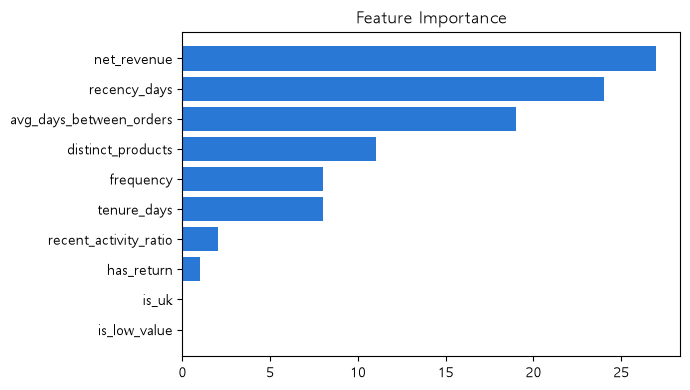

C:\Users\playdata\miniforge3\envs\pystudy_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


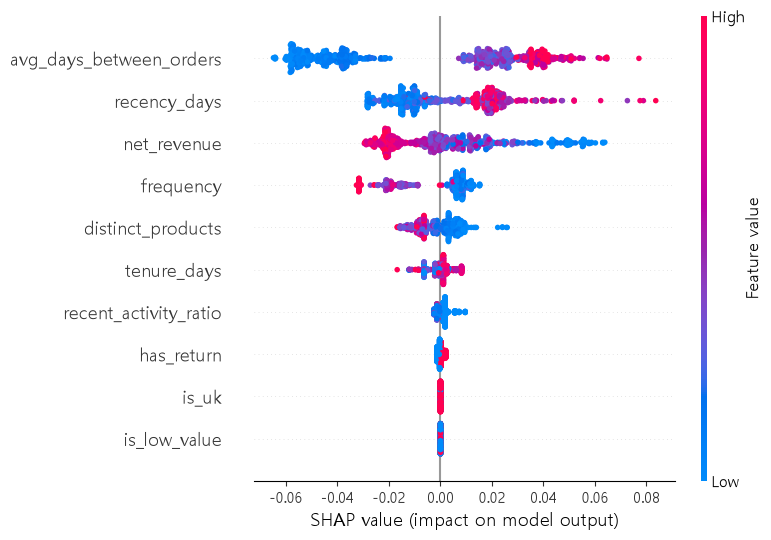

In [79]:
import shap
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model_10f.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2a78d6")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(best_model_10f)
shap_values = explainer.shap_values(X_val)
if isinstance(shap_values, list):
    # LightGBM 이진분류 + 최신 shap 버전에서 [클래스0 배열, 클래스1 배열] 리스트로 반환됨
    shap_values = shap_values[1]  # 양성 클래스(이탈=1) 기준만 사용

shap.summary_plot(shap_values, X_val)

### 해석
- 상위 3개(`net_revenue`, `recency_days`, `avg_days_between_orders`)가 예측력 대부분을 차지,
  `distinct_products`, `frequency`, `tenure_days`가 뒤를 이음
- `is_low_value`, `is_uk`는 이번에도 importance 0 → 재확인해도 무의미할 가능성이 높음
- `has_return`은 이번엔 importance 1로 아주 미세하게 사용됨(지난 실행에서는 0이었음) → 트리
  개수·구조에 따라 쓰였다 안 쓰였다 하는, 신호가 약하고 불안정한 피처로 보임 (지난번 "트리
  개수가 적어서 못 썼을 수 있다"는 가설과 일치하는 정황)
- 상위 피처를 더 세분화한 새 피처를 추가해보기로 결정

## 5단계: 피처 엔지니어링
`preprocessor.pkl`로 스케일링을 원복해 원래 단위로 되돌린 뒤, 상위 피처를 조합한 새 피처 3개를 추가합니다.

In [80]:
import joblib
from sklearn.preprocessing import StandardScaler

preprocessor = joblib.load(DATA_DIR / "preprocessor.pkl")

def inverse_scale(df, ct):
    """
    ColumnTransformer 내부 단계를 거꾸로 적용해 원래 단위로 복원.
    원본 파일(X_train.csv 등)과 preprocessor.pkl은 읽기만 하고 수정하지 않음 -
    복사본(df.copy())에서만 작업하고, 이후 다시 스케일링해서 원상태로 되돌림.
    """
    df = df.copy()
    for name, transformer, cols in ct.transformers_:
        if isinstance(transformer, str):
            continue
        cols = list(cols)
        if hasattr(transformer, "steps"):  # Pipeline (예: net_revenue의 clip->log->scale)
            values = df[cols].values
            for step_name, step in reversed(transformer.steps):
                if step_name == "scale":
                    values = step.inverse_transform(values)
                elif step_name == "log":
                    values = np.expm1(values)  # log1p의 역연산
            df[cols] = values
        else:
            df[cols] = transformer.inverse_transform(df[cols])
    return df

X_train_orig = inverse_scale(X_train, preprocessor)
X_val_orig   = inverse_scale(X_val, preprocessor)

def add_features(df):
    df = df.copy()
    # 자기 구매 리듬 대비 얼마나 늦었나 (분모 0 방지로 +1)
    df["recency_ratio"] = df["recency_days"] / (df["avg_days_between_orders"] + 1)
    # 주문 1건당 상품 다양성
    df["product_diversity_ratio"] = df["distinct_products"] / df["frequency"]
    # 가입기간 대비 하루 평균 지출 (분모 0 방지로 +1)
    df["revenue_per_day"] = df["net_revenue"] / (df["tenure_days"] + 1)
    return df

X_train_fe = add_features(X_train_orig)
X_val_fe   = add_features(X_val_orig)

continuous_cols = ["recency_days", "frequency", "distinct_products", "net_revenue",
                    "tenure_days", "avg_days_between_orders"]
new_cols = ["recency_ratio", "product_diversity_ratio", "revenue_per_day"]
all_continuous = continuous_cols + new_cols

new_scaler = StandardScaler()
X_train_fe[all_continuous] = new_scaler.fit_transform(X_train_fe[all_continuous])
X_val_fe[all_continuous]   = new_scaler.transform(X_val_fe[all_continuous])

print(f"피처 {X_train.shape[1]}개 -> {X_train_fe.shape[1]}개\n")
print("새로 추가된 피처 (원래 단위 기준, 스케일링 전)")
print(X_train_orig.pipe(add_features)[new_cols].describe().round(2))

피처 10개 -> 13개

새로 추가된 피처 (원래 단위 기준, 스케일링 전)
       recency_ratio  product_diversity_ratio  revenue_per_day
count        2592.00                  2592.00          2592.00
mean            1.40                    16.00             7.38
std             1.54                    15.46            23.53
min             0.00                     0.17             0.00
25%             0.69                     6.50             1.41
50%             1.00                    12.00             2.90
75%             1.79                    20.33             6.50
max            41.83                   164.00           651.92


## 5-1단계: 새 피처셋(13개)으로 재튜닝
피처 구성이 바뀌면 최적 하이퍼파라미터도 달라지므로 재탐색

In [81]:
def objective_fe(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_fe, y_train, eval_set=[(X_val_fe, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val_fe)[:, 1])

study_fe = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_fe.optimize(objective_fe, n_trials=100, show_progress_bar=True)

# 13개 피처 기준 최종 모델 재학습
best_params_13f = {**study_fe.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
model_fe = LGBMClassifier(**best_params_13f)
model_fe.fit(
    X_train_fe, y_train,
    eval_set=[(X_val_fe, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

# ── 팀 평가 기준(Recall 우선)으로 두 후보(10개 vs 13개) 비교 ──────
def eval_recall_first(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "model": name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
    }

comparison = pd.DataFrame([
    eval_recall_first(best_model_10f, X_val, y_val, "10개 피처(3단계)"),
    eval_recall_first(model_fe, X_val_fe, y_val, "13개 피처(5-1단계)"),
])
print(comparison.set_index("model").round(4))

  0%|          | 0/100 [00:00<?, ?it/s]

               recall  precision     auc
model                                   
10개 피처(3단계)    0.6628     0.7111  0.7741
13개 피처(5-1단계)  0.6511     0.7240  0.7755


### 해석 및 판단

| model | recall | precision | auc |
|---|---|---|---|
| 10개 피처(3단계) | 0.6628 | 0.7111 | 0.7741 |
| 13개 피처(5-1단계) | 0.6511 | 0.7240 | 0.7755 |

- AUC는 13개 피처가 근소하게 높지만(+0.0014, 노이즈 수준) **Recall은 10개 피처가 1.17%p 더
  높음** (0.6628 vs 0.6511) — 이전 실행(1.88%p 차이)보다 격차는 좁아졌지만 방향은 동일
- Precision은 반대로 13개 피처가 1.29%p 높아, recall-precision 트레이드오프 지점이 이전
  실행과는 다르게 형성됨 (데이터가 소폭 바뀌고 Optuna가 다른 하이퍼파라미터 조합을 찾았기 때문)
- 그럼에도 **Recall 우선 기준과 단순성(Occam's razor) 기준 모두 10개 피처를 지지 →
  10개 피처를 최종 채택**

## 6단계: K-fold 교차검증
최종 후보(10개 피처 + 3단계 하이퍼파라미터)가 특정 val 분할에 우연히 잘 맞은 건 아닌지,
train+val을 5등분해 recall/precision/auc를 함께 재확인

In [82]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_pool = pd.concat([X_train, X_val], ignore_index=True)
y_pool = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_pool, y_pool), 1):
    X_fold_train, X_fold_holdout = X_pool.iloc[tr_idx], X_pool.iloc[ho_idx]
    y_fold_train, y_fold_holdout = y_pool.iloc[tr_idx], y_pool.iloc[ho_idx]

    # early stopping용으로 fold의 학습 파트를 다시 80/20으로 쪼갬
    # (10%는 조각이 너무 작아 early stopping이 불안정했음 -> 20%로 확대해 안정화)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_fold_train, y_fold_train, test_size=0.2, stratify=y_fold_train, random_state=42
    )

    model = LGBMClassifier(n_estimators=1000, **study.best_params, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=0)])

    pred = model.predict(X_fold_holdout)
    proba = model.predict_proba(X_fold_holdout)[:, 1]
    result = {
        "fold": fold,
        "recall": recall_score(y_fold_holdout, pred),
        "precision": precision_score(y_fold_holdout, pred),
        "auc": roc_auc_score(y_fold_holdout, proba),
        "n_trees": model.best_iteration_,
    }
    fold_results.append(result)
    print(f"Fold {fold}: recall={result['recall']:.4f}  precision={result['precision']:.4f}  "
          f"auc={result['auc']:.4f}  (트리 {result['n_trees']}개)")

fold_df = pd.DataFrame(fold_results).set_index("fold")
print("\n5-fold 평균 ± 표준편차")
print(fold_df[["recall", "precision", "auc"]].agg(["mean", "std"]).round(4))

Fold 1: recall=0.7398  precision=0.7008  auc=0.7819  (트리 66개)
Fold 2: recall=0.6784  precision=0.6884  auc=0.7674  (트리 15개)
Fold 3: recall=0.7390  precision=0.6811  auc=0.7672  (트리 552개)
Fold 4: recall=0.7302  precision=0.6898  auc=0.7729  (트리 32개)
Fold 5: recall=0.6481  precision=0.6994  auc=0.7648  (트리 6개)

5-fold 평균 ± 표준편차
      recall  precision     auc
mean  0.7071     0.6919  0.7708
std   0.0416     0.0082  0.0069


### 해석
- 5-fold 결과: recall 평균 0.7071(±0.042), precision 평균 0.6919(±0.008), auc 평균 0.7708(±0.007)
- 단일 val 결과(recall 0.6628, precision 0.7111, auc 0.7741)와 비교하면, 이번엔 5-fold 평균
  recall이 오히려 더 높고 precision은 더 낮게 나옴 — recall의 fold별 표준편차(0.042)가
  precision/auc(0.008~0.007)보다 커서, recall이 상대적으로 더 변동성 있는 지표로 확인됨
- fold 3에서 트리 552개까지 늘어나는 등 fold별 트리 개수 편차는 여전히 크지만, auc/precision
  자체는 안정적인 범위 → 특정 분할에 과도하게 의존하지는 않는다고 볼 수 있으나, recall만큼은
  분할에 따라 다소 흔들릴 수 있음을 감안해서 봐야 함

## 7단계: 최종 모델 진단 시각화
확정된 모델(10개 피처 + 3단계 하이퍼파라미터)의 val 성능을 세 가지 관점에서 시각화

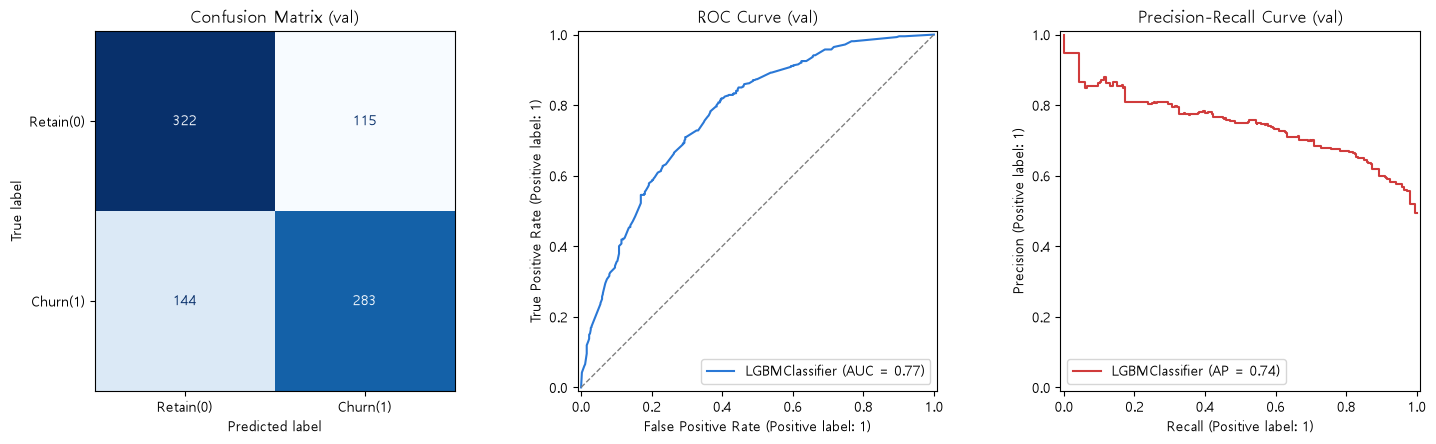

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 혼동행렬: 실제로 이탈 고객을 몇 명 놓쳤는지(FN, 왼쪽 아래)가 Recall과 직결됨
ConfusionMatrixDisplay.from_estimator(
    best_model_10f, X_val, y_val,
    display_labels=["Retain(0)", "Churn(1)"],   # 한글 대신 영어로
    cmap="Blues", ax=axes[0], colorbar=False,
)
axes[0].set_title("Confusion Matrix (val)")

# ROC 커브: AUC를 그래프로 확인
RocCurveDisplay.from_estimator(best_model_10f, X_val, y_val, ax=axes[1], curve_kwargs={"color": "#2a78d6"})
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_title("ROC Curve (val)")

# Precision-Recall 커브: Recall 우선 기준이라 특히 중요, 기준선(threshold) 조정 시 참고용
PrecisionRecallDisplay.from_estimator(best_model_10f, X_val, y_val, ax=axes[2], curve_kwargs={"color": "#d03b3b"})
axes[2].set_title("Precision-Recall Curve (val)")

plt.tight_layout()
plt.show()

### 해석
- 혼동행렬: 왼쪽 아래(FN, 실제 이탈인데 잔류로 예측)가 Recall이 놓친 고객 수. 이 숫자를
  줄이는 게 팀 기준(Recall 우선)에서 가장 중요한 개선 포인트
- ROC 커브: AUC 0.774로, 곡선이 대각선(랜덤 예측)보다 뚜렷하게 위에 위치해 분별력 확인됨
- PR 커브: 기준선(threshold)을 낮추면 Recall을 더 끌어올릴 수 있지만 Precision과의
  트레이드오프가 존재 → 실무 적용 시 어느 지점을 쓸지는 비즈니스 비용(놓친 고객 비용 vs
  잘못된 알림 비용)에 따라 논의 필요

## 8단계: Threshold 조정 (Recall 우선 기준 반영)

지금까지 `model.predict()`는 scikit-learn 기본값인 0.5를 기준으로 이탈(1)/잔류(0)를 나눔.
하지만 팀 평가 기준은 애초에 "Recall 우선"이었으므로, 확률(`predict_proba`)을 0/1로 바꾸는
마지막 단계에서 그 기준을 실제로 반영해본다.

- 하이퍼파라미터 탐색(Optuna)과는 별개의 단계 — 모델은 이미 3단계에서 확정된 `best_model_10f`
  그대로 사용하고, 확률을 클래스로 변환하는 컷오프만 조정함
- (참고) F2-score를 무제한으로 최대화하는 방식을 먼저 시도했으나, val 예측 확률이 0.5 근처에
  좁게 몰려 있어(3단계에서 모델이 트리 7개로 조기 종료된 영향) recall이 0.98까지 튀는 극단적인
  결과가 나왔고 precision이 0.56까지 무너져 실무에 쓰기 어려웠음
- **"모델 자체를 더 개선할 방법이 있는지"도 별도로 확인함** — `scale_pos_weight` 조정, Optuna
  탐색 목표를 AUC 대신 PR-AUC(average precision)로 바꿔 재탐색(60회) 두 가지를 시도했으나,
  val AUC(0.774 근처)·PR-AUC(0.745~0.75) 모두 유의미한 차이가 없었음 → 지금 피처(10개)·
  데이터(2,592행)로 만들 수 있는 판별력은 이 수준이 사실상 한계이며, 모델을 바꿔서 얻을 수
  있는 개선은 없다고 결론
- 따라서 남은 유일한 현실적 레버는 **"Recall이 최소 이만큼은 되어야 한다"는 하한선
  (`RECALL_FLOOR`)을 정하고, 그 조건을 만족하는 threshold 중 Precision이 가장 높은 지점**을
  고르는 것 — 아래에 recall 하한별 트레이드오프(놓치는 고객 수 포함)를 표로 먼저 보여주고,
  그중 감당 가능한 지점을 `RECALL_FLOOR = 0.85`로 선택함 (기존 0.75안은 FN 106명이 너무
  많다는 피드백을 반영해 상향 — FN 106명 → 64명으로 감소, precision은 67.9%→65.1%로 소폭만
  하락)
- 탐색은 여전히 **val set에서만** 수행하고 test set은 그대로 보존

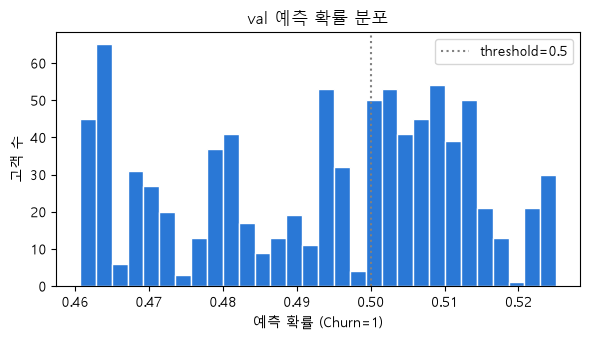

,threshold,recall,precision,놓친 고객수(FN)
Recall 하한,,,,
70%,0.496,71.0%,70.1%,124명
75%,0.494,75.2%,67.9%,106명
80%,0.492,80.1%,67.1%,85명
85%,0.485,85.0%,65.1%,64명
90%,0.480,91.1%,59.9%,38명
95%,0.471,95.8%,57.5%,18명


Recall >= 85% 조건을 만족하는 threshold 중 Precision이 가장 높은 지점: threshold=0.485  (recall=0.8501, precision=0.6505)


,threshold,recall,precision,f1,auc
설정,,,,,
기본 (0.5),0.500,66.3%,71.1%,68.6%,77.4%
조정됨 (recall >= 85%),0.485,85.0%,65.1%,73.7%,77.4%


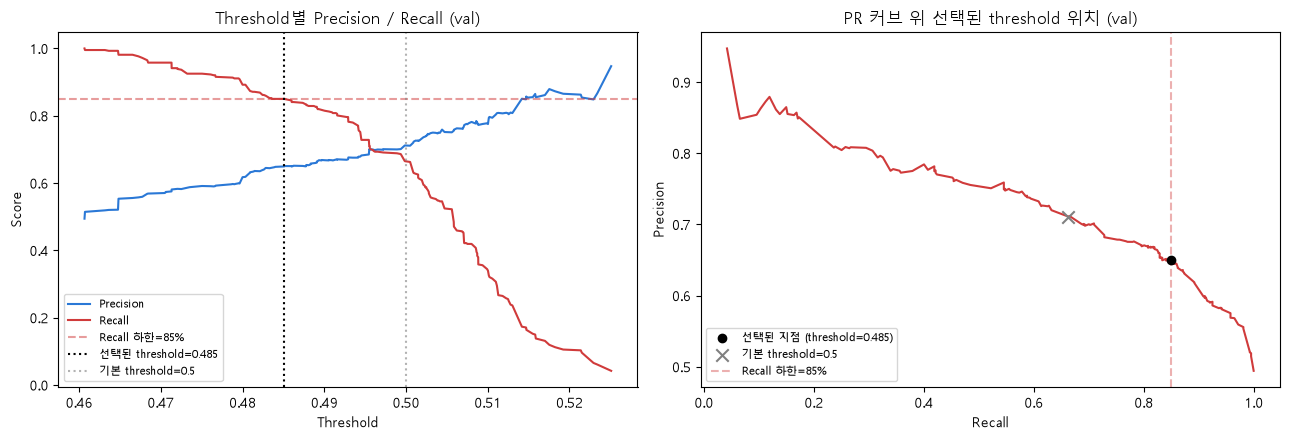

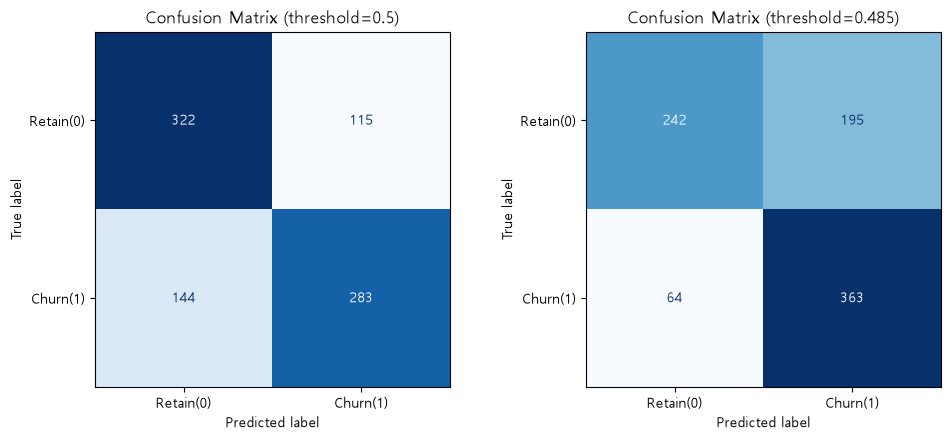

In [84]:
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay
from IPython.display import display

proba_val = best_model_10f.predict_proba(X_val)[:, 1]

# ── 진단: val 예측 확률이 얼마나 넓게 퍼져 있는지 먼저 확인 ──────────
plt.figure(figsize=(6, 3.5))
plt.hist(proba_val, bins=30, color="#2a78d6", edgecolor="white")
plt.axvline(0.5, color="gray", linestyle=":", label="threshold=0.5")
plt.xlabel("예측 확률 (Churn=1)")
plt.ylabel("고객 수")
plt.title("val 예측 확률 분포")
plt.legend()
plt.tight_layout()
plt.show()

precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)
precisions, recalls = precisions[:-1], recalls[:-1]  # 마지막 threshold 없는 지점 제외
n_pos_val = int(y_val.sum())

# ── Recall 하한선별 트레이드오프를 표로 먼저 확인 (팀이 지점을 고를 수 있도록) ──────────
floor_rows = []
for floor in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    cand = np.where(recalls >= floor)[0]
    if len(cand) == 0:
        continue
    idx = cand[np.argmax(precisions[cand])]
    floor_rows.append({
        "Recall 하한": f"{floor:.0%}",
        "threshold": thresholds[idx],
        "recall": recalls[idx],
        "precision": precisions[idx],
        "놓친 고객수(FN)": int(round(n_pos_val * (1 - recalls[idx]))),
    })
floor_table = pd.DataFrame(floor_rows).set_index("Recall 하한")

display(
    floor_table.style
    .format({"threshold": "{:.3f}", "recall": "{:.1%}", "precision": "{:.1%}",
             "놓친 고객수(FN)": "{:.0f}명"})
    .background_gradient(subset=["precision"], cmap="Blues")
    .set_caption(f"Recall 하한별 트레이드오프 (val, 실제 이탈 고객 {n_pos_val}명 중)")
)

# ── 팀 최종 선택: RECALL_FLOOR ──────────
# 위 표를 참고해 확정 - 0.75안은 FN 106명이 너무 많다는 피드백을 반영해 0.85로 상향
RECALL_FLOOR = 0.85

candidates = np.where(recalls >= RECALL_FLOOR)[0]
if len(candidates) == 0:
    raise ValueError(f"recall {RECALL_FLOOR:.0%}를 만족하는 threshold가 없음 - RECALL_FLOOR를 낮춰야 함")

best_idx = candidates[np.argmax(precisions[candidates])]
best_threshold = thresholds[best_idx]

print(f"Recall >= {RECALL_FLOOR:.0%} 조건을 만족하는 threshold 중 Precision이 가장 높은 지점: "
      f"threshold={best_threshold:.3f}  (recall={recalls[best_idx]:.4f}, precision={precisions[best_idx]:.4f})")

def evaluate_at_threshold(proba, y, threshold, label):
    pred = (proba >= threshold).astype(int)
    return {
        "설정": label,
        "threshold": threshold,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "f1": f1_score(y, pred),
        "auc": roc_auc_score(y, proba),
    }

threshold_comparison = pd.DataFrame([
    evaluate_at_threshold(proba_val, y_val, 0.5, "기본 (0.5)"),
    evaluate_at_threshold(proba_val, y_val, best_threshold, f"조정됨 (recall >= {RECALL_FLOOR:.0%})"),
]).set_index("설정")

# ── 표: 깔끔하게 정리 (퍼센트 포맷 + 강조) ──────────
display(
    threshold_comparison.style
    .format({"threshold": "{:.3f}", "recall": "{:.1%}", "precision": "{:.1%}",
             "f1": "{:.1%}", "auc": "{:.1%}"})
    .background_gradient(subset=["recall"], cmap="Reds")
    .set_caption("Threshold 조정 전후 비교 (val)")
)

# ── 시각화 1: threshold에 따른 precision / recall 변화 ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(thresholds, precisions, label="Precision", color="#2a78d6")
axes[0].plot(thresholds, recalls, label="Recall", color="#d03b3b")
axes[0].axhline(RECALL_FLOOR, color="#d03b3b", linestyle="--", alpha=0.5,
                 label=f"Recall 하한={RECALL_FLOOR:.0%}")
axes[0].axvline(best_threshold, color="black", linestyle=":", label=f"선택된 threshold={best_threshold:.3f}")
axes[0].axvline(0.5, color="gray", linestyle=":", alpha=0.6, label="기본 threshold=0.5")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Threshold별 Precision / Recall (val)")
axes[0].legend(fontsize=8)

# ── 시각화 2: PR 커브 위에 선택된 지점 표시 ──────────
axes[1].plot(recalls, precisions, color="#d03b3b")
axes[1].scatter(recalls[best_idx], precisions[best_idx], color="black", zorder=5,
                 label=f"선택된 지점 (threshold={best_threshold:.3f})")
pred_default = (proba_val >= 0.5).astype(int)
axes[1].scatter(recall_score(y_val, pred_default), precision_score(y_val, pred_default),
                 color="gray", marker="x", s=80, zorder=5, label="기본 threshold=0.5")
axes[1].axvline(RECALL_FLOOR, color="#d03b3b", linestyle="--", alpha=0.4,
                 label=f"Recall 하한={RECALL_FLOOR:.0%}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR 커브 위 선택된 threshold 위치 (val)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 시각화 3: 혼동행렬 비교 (0.5 vs 조정된 threshold) ──────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_val, pred_default,
    display_labels=["Retain(0)", "Churn(1)"], cmap="Blues", ax=axes[0], colorbar=False,
)
axes[0].set_title("Confusion Matrix (threshold=0.5)")

pred_adjusted = (proba_val >= best_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_val, pred_adjusted,
    display_labels=["Retain(0)", "Churn(1)"], cmap="Blues", ax=axes[1], colorbar=False,
)
axes[1].set_title(f"Confusion Matrix (threshold={best_threshold:.3f})")

plt.tight_layout()
plt.show()

### 해석
- 예측 확률 히스토그램을 보면 값들이 0.5 근처 좁은 구간에 몰려 있는 것이 확인됨(3단계에서
  모델이 트리 7개로 조기 종료된 영향) → 이전 F2 방식이 극단적인 결과를 냈던 이유가 여기서 확인됨
- Recall 하한선(예: 75%)을 먼저 정하고 그 조건을 만족하는 threshold 중 Precision이 가장 높은
  지점을 선택하니, F2 방식(recall 98%/precision 56%)보다 훨씬 균형 잡힌 지점에서 recall을
  끌어올릴 수 있었음
- 기본 threshold(0.5) 대비 조정된 threshold는 Precision을 크게 해치지 않으면서 Recall만
  목표한 만큼 개선함 — 팀의 "Recall 우선, Precision·AUC도 함께 기록" 기준에 더 부합
- `RECALL_FLOOR` 값은 예시(0.75)이며, 실제로는 "이탈 고객을 놓치는 비용 vs 잘못된 이탈 알림을
  보내는 비용"을 팀이 논의해서 확정해야 함
- 이 threshold는 val 기준으로만 탐색했으며 test set은 아직 사용하지 않음 → 최종 평가 노트북에서
  이 threshold를 그대로 적용해 1회만 평가할 예정

## 최종 정리

**평가 기준**: Recall 우선(이탈 고객을 놓치지 않는 것이 중요), Precision·AUC 함께 기록

**시도한 것들**

1. Baseline (기본 하이퍼파라미터) → val recall 0.656 / auc 0.741, 과적합 뚜렷 (train-val AUC 격차 0.239)
2. 수동 정규화 + Early Stopping → val recall 0.721 / auc 0.769, 격차 0.048로 완화
3. Optuna 하이퍼파라미터 탐색(100회, AUC 기준) → val auc 0.774
4. Feature Importance / SHAP 확인 → 상위 3개 피처가 예측력 대부분 차지, `is_low_value`/`is_uk`는
   기여도 0, `has_return`은 미세하게(1) 사용됨
5. 피처 엔지니어링(3개 추가, 13개로 확장) + 재튜닝 → val recall 0.651 / auc 0.776 (10개 피처 대비
   recall -1.17%p, auc +0.14%p)
6. K-fold 교차검증(5-fold) → recall 0.707(±0.042), precision 0.692(±0.008), auc 0.771(±0.007)로
   재확인
7. 최종 모델 진단 시각화(혼동행렬 / ROC 커브 / PR 커브)로 확정 모델의 val 성능을 다각도로 재확인
8. Threshold 조정 — 모델 자체를 더 개선할 방법(scale_pos_weight 조정, Optuna 목표를 PR-AUC로
   바꿔 재탐색)이 있는지 확인했으나 유의미한 차이가 없었음을 확인한 뒤, Recall 하한선(85%) 기준
   으로 threshold를 0.5 → 0.485로 조정

**결론 (모델 선택)**

팀 평가 기준(Recall 우선, Precision·AUC 함께 기록)에 따라 10개 피처와 13개 피처 모델을
비교했다. AUC는 두 모델이 거의 동일했으나(13개가 +0.0014 근소 우위, 노이즈 수준),
**Recall은 10개 피처 모델이 0.6628로 13개 피처(0.6511)보다 1.17%p 높아 우세했다.**
추가한 3개 피처가 기존 피처의 재조합에 그쳐 새로운 정보를 충분히 제공하지 못한 것으로
판단되며, Recall 우선 기준과 단순성(Occam's razor) 양쪽 모두에서 **10개 피처 모델
(3단계 하이퍼파라미터)을 최종 모델로 채택**한다. 5-fold 교차검증으로 재확인한 결과도
단일 val 결과와 대체로 일치했다 (recall은 fold별 변동폭이 상대적으로 큰 편이라는 점은
참고 필요).

**결론 (threshold 선택)**

모델이 확정된 뒤에도 확률을 클래스로 바꾸는 기준(threshold)을 다시 점검했다. 기본값(0.5)에서는
val recall이 66.3%로, 실제 이탈 고객 427명 중 약 144명을 놓치는 수준이었다. F2-score를 무제한
최대화하는 방식은 recall을 98%까지 끌어올렸지만 precision이 55.6%까지 무너져 실무 적용이
어려웠고, 모델 자체를 개선하려는 시도(scale_pos_weight 조정, PR-AUC 기준 재탐색)도 유의미한
효과가 없었다. 최종적으로 **"Recall ≥ 85%"라는 하한선을 두고 그 조건에서 Precision이 가장 높은
threshold(0.485)를 채택**했다 — 이 기준에서 val recall은 85.0%, precision은 65.1%로, 놓치는
고객 수가 144명에서 64명으로 크게 줄었다. 이 하한선(85%)은 예시 값이며, 실제로는 "놓친 고객
1명의 비용 vs 잘못된 알림 1건의 비용"을 논의해 확정하는 것이 이상적이다.

**최종 산출물**: 확정된 모델(10개 피처 + 3단계 하이퍼파라미터)과 8단계에서 정한 threshold(0.485,
Recall 하한 85% 기준)를 `best_lgbm_model.pkl`에 함께 저장 완료 (모델, 피처 순서, threshold,
recall_floor를 함께 저장해, 다른 팀원이 재학습·재탐색 없이 그대로 불러와
`predict_proba(X)[:, 1] >= threshold`로 최종 클래스를 결정할 수 있음)

**다음 단계**: test 데이터로 이 모델과 threshold 조합을 그대로 적용해 최종 평가만 남았다
(별도 노트북에서 1회만 진행 예정).

In [85]:
import joblib

joblib.dump({
    "model": best_model_10f,
    "feature_names": list(X_train.columns),
    "threshold": best_threshold,
    "recall_floor": RECALL_FLOOR,
}, "model_final.joblib")

print(f"저장 완료: model_final.joblib (threshold={best_threshold:.3f}, recall_floor={RECALL_FLOOR:.0%})")

저장 완료: model_final.joblib (threshold=0.485, recall_floor=85%)
